# FVmax analysis

Works with jupyterlab3 on ppmstar.org

Measure the evolution of the heigth of the FV Gaussians

In [2]:
%pylab ipympl
from astropy import units
from nugridpy import utils as ut
from scipy import interpolate
from scipy import stats
from scipy.optimize import curve_fit 
from scipy.optimize import minimize
import sys
ppmpy_dir = '/home/user/user/trillium_scratch/fherwig/niagara_scratch/repos-simon/PyPPM'
sys.path.insert(0,ppmpy_dir)
from ppmpy import ppm  
logging.getLogger("matplotlib").setLevel(logging.ERROR)
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table
import pymannkendall as mk
code_mass = 5.025e-07  # code unit of mass in solar masses

Populating the interactive namespace from numpy and matplotlib


In [4]:
def where_near(t,tt_arr,num_arr=None):
    '''Finds n in num that corresponds closest to t in tt_sec
    
    Parameters:
    -----------
    
    t :: scalar, float
      time in seconds we seek the dump number for
    
    tt_arr : array, float
      time in seconds for each dump
      
    num_arr :: array, int or float
      dump number array
      The default is that num_arr is the grid number, and then 
      the input, for example, (R, Rgrid) will return the neares grid 
      number of R in the Rgrid array.
    
    Returns:
    --------
    
    num_t :: int/float depending on type of NDump
      interpolated value in num_arr corresponding to t in tt_arr
    
    '''
    if num_arr is None:
        num_arr = arange(0,len(tt_arr),1)
    f_int = interpolate.interp1d(tt_arr,num_arr,kind='linear',fill_value="extrapolate")
    num_t = float(f_int(t))
    if type(num_arr[0]) in [int64,int]: 
        num_t = int(round(num_t,0))
    return num_t


In [5]:
def initialize(data,dir,cases,nominal_heat = 1,eos='g'):
    '''Initialize Rprof data for one run
    
    nominal_heat   nominal heat, from PPMstar code, so that X_Lfactors is factor wrt nominal heat
    '''
    for case in cases:
        data[case] = {}
        data[case]['path'] = dir+case+'/prfs' 
        data[case]['rp'] = ppm.RprofSet(data[case]['path'] )
        data[case]['rph'] = data[case]['rp'].get_history()
        data[case]['NDump'] = data[case]['rph'].get('NDump')
        data[case]['time(mins)'] = data[case]['rph'].get('time(mins)')
        data[case]['time(secs)'] = data[case]['rph'].get('time(secs)')
        data[case]['rp_one'] = data[case]['rp'].get_dump(data[case]['NDump'][0])
        data[case]['X_Lfactors'] = data[case]['rp_one'].get('totallum')/nominal_heat
        data[case]['grids'] = data[case]['rp_one'].get('Nx') 
        data[case]['eos'] = eos        
    return data

In [6]:
# Data dictionary to hold the data for the different cases analysed in this nb
data = {}  
cases = []

In [7]:
eos = 'r'
dir = '/home/user/user/frontera_scratch3_pwoodwar/'
cases1 = ['X39-2688-xL-mc12400-rot-77kms']
data = initialize(data,dir, cases1,eos=eos)

1027 rprof files found in '/home/user/user/frontera_scratch3_pwoodwar/X39-2688-xL-mc12400-rot-77kms/prfs/.
Dump numbers range from 0 to 1026.


In [8]:
all_cases = list(data.keys())
cases = all_cases 
cases

['X39-2688-xL-mc12400-rot-77kms']

In [9]:
def gauss(x, *p):
    A, mu, sigma = p
    return A*np.exp(-(x-mu)**2/(2.*sigma**2))

Text(0, 0.5, 'FV')

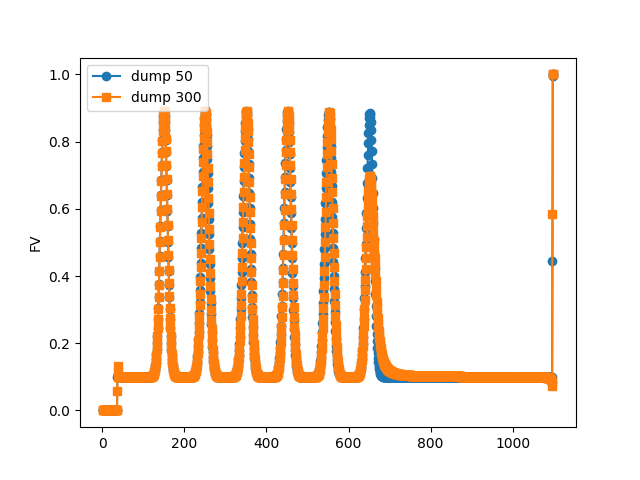

In [10]:
case = all_cases[0]
rpo = data[case]['rp_one']
close(1679);figure(1679)
dump = 50
m = data[case]['rp'].compute_m(dump)*code_mass
FV = data[case]['rp'].get('FV',fname=dump)
R = data[case]['rp'].get('R',fname=dump)
plot(R,FV,'-o',label='dump '+str(dump))
dump = 300
m = data[case]['rp'].compute_m(dump)*code_mass
FV = data[case]['rp'].get('FV',fname=dump)
R = data[case]['rp'].get('R',fname=dump)
plot(R,FV,'-s', label='dump '+str(dump))
#xlim(0.4685,0.4714)

legend()
# xlabel('$m_r$ [Msun]')
ylabel('FV')

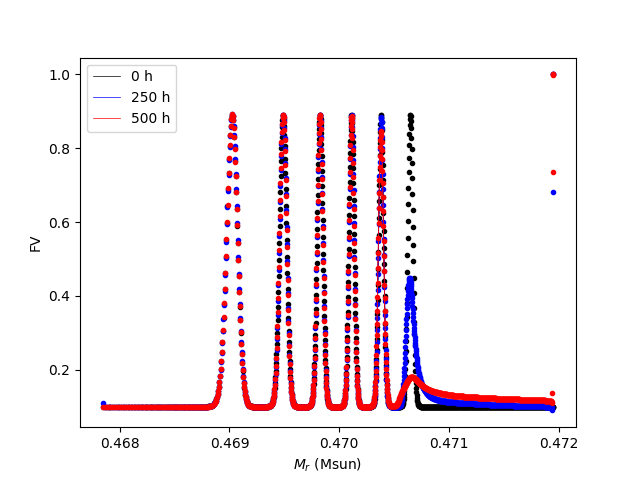

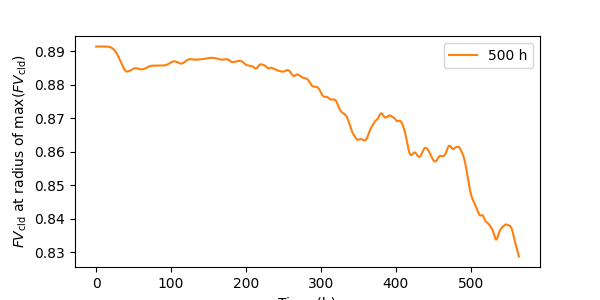

In [15]:
%%capture --no-display
# 
key = "FVcld_max"

close(56);figure(56)
h0,h1,h2 = 0,250,500

case = cases[0]
logy = False
sparse = 1.
num_type = 't' 

mlims = (.47034,.47042) #5th peak
# mlims = (.4701,.47014) #4th peak
# mlims = (.4698+1e-5,.4698+5e-5) #3rd peak

code_mass = 5.025e-07  # code unit of mass in solar masses
s = 0
t_s_per_hr = 3600
ifig=1394; close(ifig); figure(ifig,figsize=(6,3))
out_dat = {}
for i,case in enumerate(cases):
    m_hr = arange(*mlims,0.00000001)
    out_dat[case] = {}
    print("Case: {:s}".format(case))
    FVmax = []
    mass_FVmax = []
    radius_FVmax = []
    Rhos_FVmax = []
    Umags_FVmax = []
    times = []
    coeffs = []
    perrs = []
    last_dumps = data[case]['NDump'][-1]
    last_hour = floor(data[case]['rp'].get('t',fname=last_dumps)/3600)
    hour_vec = arange(0,last_hour,sparse)
    for hour in hour_vec:
        print(hour)
        dump = hour * t_s_per_hr
        m = data[case]['rp'].compute_m(dump,num_type=num_type)*code_mass
        FV = data[case]['rp'].get('FV',fname=dump,num_type=num_type)
        R = data[case]['rp'].get('R',fname=dump,num_type=num_type)
        Rho = data[case]['rp'].get('Rho0',fname=dump,num_type=num_type)+\
            data[case]['rp'].get('Rho1',fname=dump,num_type=num_type)
        dm = diff(m, append=m[-1])
        try:
            Umag = data[case]['rp'].get('|U|',fname=dump,num_type=num_type)
            Umag = Umag[dm!=0]
        except:
            Umag = data[case]['rp'].get('|U1|',fname=dump,num_type=num_type)
            Umag = Umag[dm!=0]
        # S Blouin
        # Remove dm=0 portion
        
        FV = FV[dm!=0]
        R = R[dm!=0]
        Rho = Rho[dm!=0]
        
        m = m[dm!=0]
        #
        f_R_from_m = interpolate.interp1d(m,R,kind='linear',fill_value="extrapolate")
        rlims = f_R_from_m(mlims)
        r_hr = arange(*rlims,0.1)
        #
        # spline fit and find max
        f_Pchip = interpolate.PchipInterpolator(m[::-1],FV[::-1], axis=0, extrapolate=None) 
        tck = interpolate.splrep(m[::-1],FV[::-1], s=s)
        FV_hr = interpolate.splev(m_hr, tck, der=0)
        if hour==h0 or hour==h1 or hour==h2:
            figure(56)
            if hour==h0: color='k';label=f'{h0} h'
            if hour==h1: color='b';label=f'{h1} h'
            if hour==h2: color='r';label=f'{h2} h'
            if 'frontera' in case:
                alpha = 0.5
            else:
                alpha = 1.0
            plot(m_hr,FV_hr,'-',lw=.5,color=color,label=label, alpha=alpha)
            plot(m,FV,'.',color=color)
        FVmax.append(max(FV_hr))
        mass_FVmax.append(m_hr[where(max(FV_hr)==FV_hr)[0][0]])
#         FVmax.append(min(FV_hr))
#         mass_FVmax.append(m_hr[where(min(FV_hr)==FV_hr)[0][0]])
        f_Pchip = interpolate.PchipInterpolator(R[::-1],FV[::-1], axis=0, extrapolate=None) 
        tck = interpolate.splrep(R[::-1],FV[::-1], s=s)
        FV_hr = interpolate.splev(r_hr, tck, der=0)
        Rh_FVmax = r_hr[where(max(FV_hr)==FV_hr)[0][0]]
        radius_FVmax.append(Rh_FVmax)
        rho_FVmax = where_near(Rh_FVmax,R,Rho)
        Rhos_FVmax.append(rho_FVmax)
        Umag_FVmax =  where_near(Rh_FVmax,R,Umag)
        Umags_FVmax.append(Umag_FVmax)
        times.append(data[case]['rp'].get('t',fname=dump,num_type=num_type)/60.) # times in min
        #
        # Gauss fit
        ind    = (R > rlims[0])*(R < rlims[1]) 
        print(ind, R)
        Rmax = R[ind][(FV[ind] == max(FV[ind]))][0]
        p0 = [FVmax[-1], Rmax, 8]
        coeff, var_matrix = curve_fit(gauss, R[ind],FV[ind]-0.1, p0=p0)
        if hour==h0 or hour==h1 or hour==h2:
            figure(56)
            if hour==h0: color='k'
            if hour==h1: color='b'
            if hour==h2: color='r'
            plot(m_hr,gauss(f_R_from_m(m_hr),*coeff)+.1,'--',lw=.5,color=color)
        perr = np.sqrt(np.diag(var_matrix))
        coeffs.append(coeff)
        perrs.append(perr)
    FVmax = array(FVmax); times = array(times); coeffs = array(coeffs); perrs = array(perrs)
    mass_FVmax = array(mass_FVmax ); Umags_FVmax = array(Umags_FVmax)
    out_dat[case]['FVmax']=FVmax; out_dat[case]['times']=times; out_dat[case]['mass_FVmax']=mass_FVmax
    out_dat[case]['radius_FVmax']=radius_FVmax; out_dat[case]['coeffs']=coeffs; out_dat[case]['perrs']=perrs
    ifig=1394;  figure(ifig)
    plot(times/60.,FVmax,ut.linestylecb(i)[0],color=ut.colourblind(i+1),\
             label=label)

figure(56)
legend()
ylabel('FV')
xlabel(r'$M_r$ (Msun)')